# Transparency and fairness analysis for the Adult Census Income dataset
Etudiante : Ameni Jomaa

DSML


# **Understanding the Dataset**
The Adult Census Income dataset contains demographic and employment-related attributes to predict whether an individual earns more than $50K per year.
Key Features:
* **Demographic attributes:** Age, sex, race, marital status, education, native country.
* **Employment-related attributes:** Occupation, work class, hours per week, capital gain/loss.
* **Target Variable:** Income (>50K or <=50K).

# **Potential Bias Sources:**

1. **Sex Bias:** Income disparities between males and females.
2. **Race Bias:** Potential differences in income levels across racial groups.
3. **Occupation Bias:** Certain groups may be over/underrepresented in high-paying jobs.
4. **Education Bias:** Disparities in income based on education level.

# Steps:
* ✅ Data loading & preprocessing
* ✅ Exploratory Data Analysis (EDA)
* ✅ Baseline model training (Logistic Regression)
* ✅ Fairness evaluation (using fairlearn)
* ✅ Bias mitigation techniques
* ✅ Explainability analysis (using SHAP)
* ✅ Conclusion

# *✅ Data loading & preprocessing*

In [ ]:
!pip install pandas numpy scikit-learn matplotlib seaborn fairlearn shap aif360

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 240.0/240.0 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.7/259.7 kB 10.3 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from fairlearn.metrics import demographic_parity_difference, equalized_odds_difference
from fairlearn.postprocessing import ThresholdOptimizer
import shap

In [ ]:
# Load dataset
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/adult/adult.data"
columns = ['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status',
           'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss',
           'hours-per-week', 'native-country', 'income']
df = pd.read_csv(url, names=columns, na_values=' ?', skipinitialspace=True)

In [ ]:
# Check the first few rows
df.head()


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


# ✅ Exploratory Data Analysis (EDA)

In [ ]:
# Check for missing values
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0


In [ ]:
# Check data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education-num   32561 non-null  int64 
 5   marital-status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital-gain    32561 non-null  int64 
 11  capital-loss    32561 non-null  int64 
 12  hours-per-week  32561 non-null  int64 
 13  native-country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [ ]:
# Summary statistics for numerical columns
df.describe()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [ ]:
# Summary statistics for categorical columns
df.describe(include='object')

,workclass,education,marital-status,occupation,relationship,race,sex,native-country,income
count,32561,32561,32561,32561,32561,32561,32561,32561,32561
unique,9,16,7,15,6,5,2,42,2
top,Private,HS-grad,Married-civ-spouse,Prof-specialty,Husband,White,Male,United-States,<=50K
freq,22696,10501,14976,4140,13193,27816,21790,29170,24720


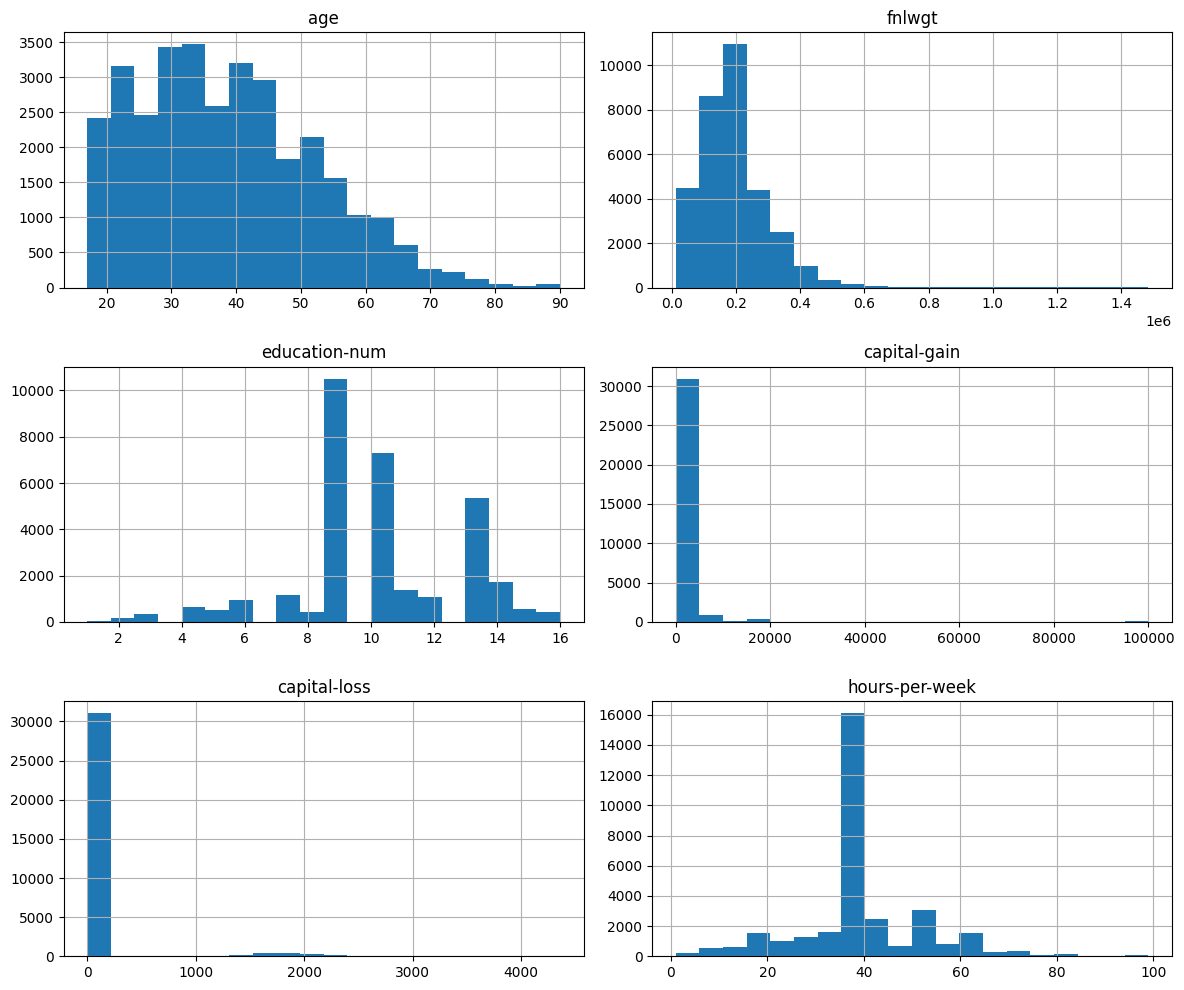

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot histograms for numerical columns
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns
df[numerical_columns].hist(figsize=(12, 10), bins=20)
plt.tight_layout()
plt.show()


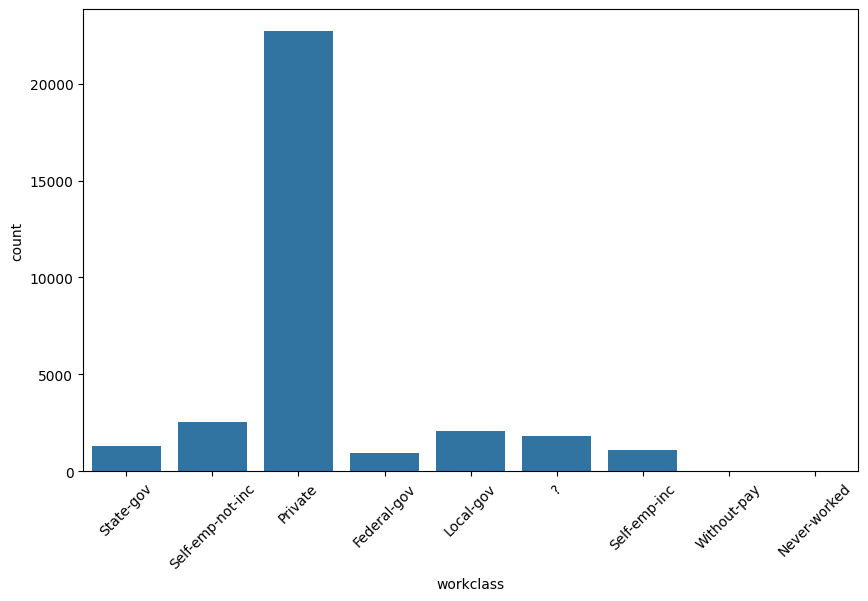

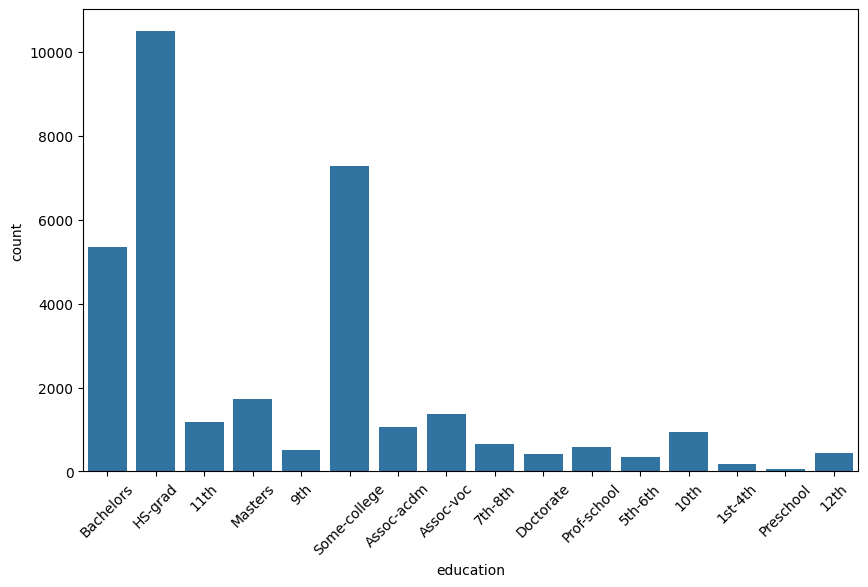

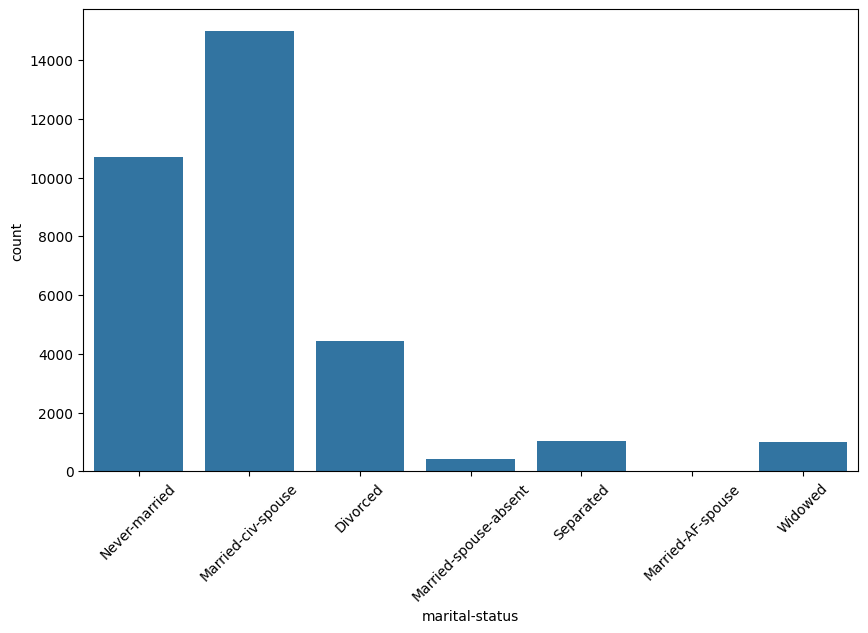

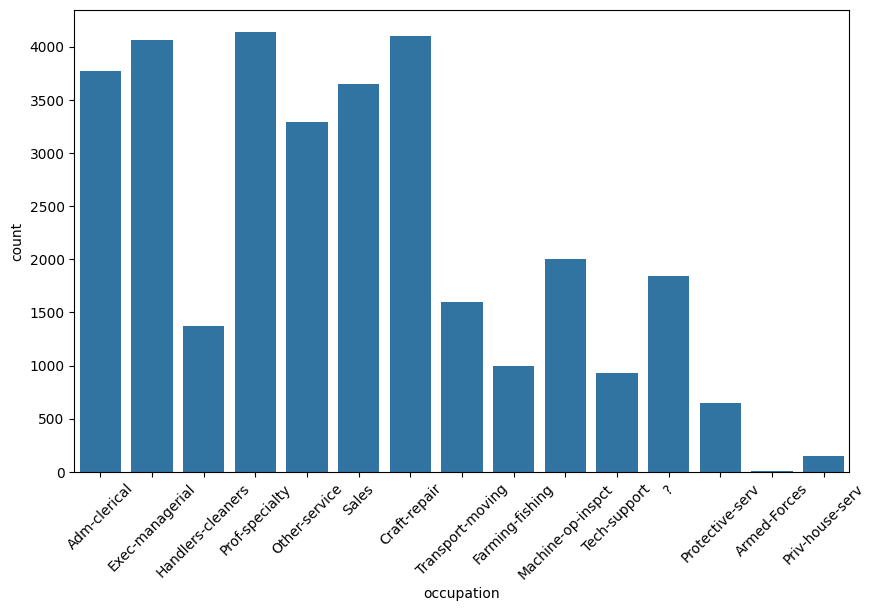

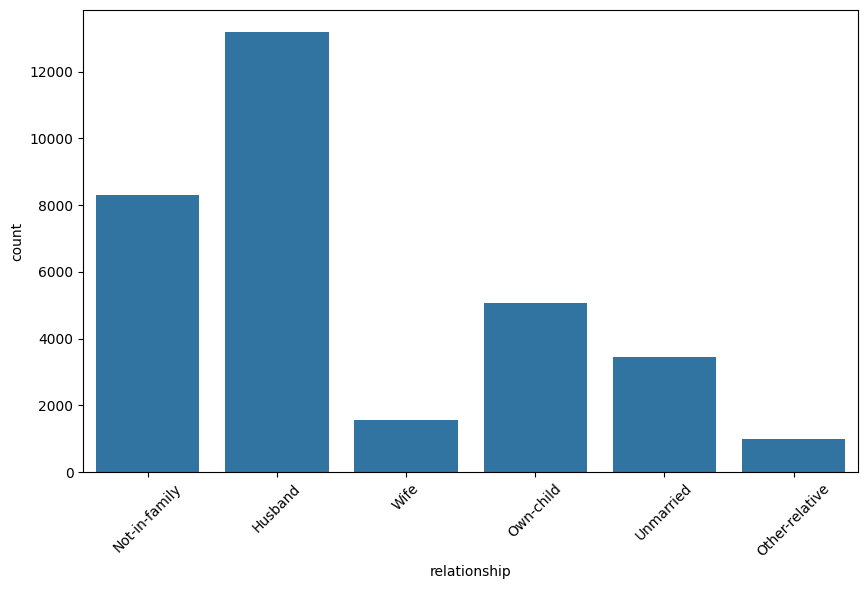

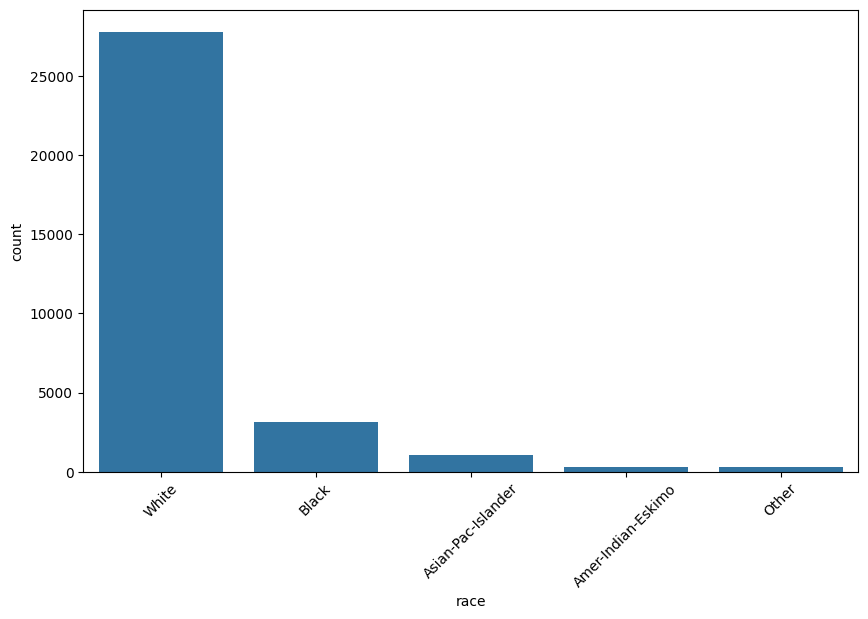

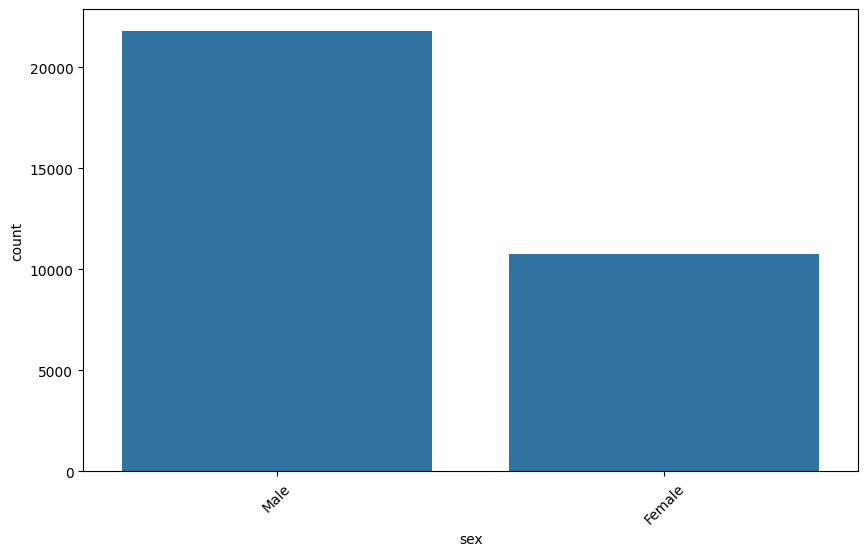

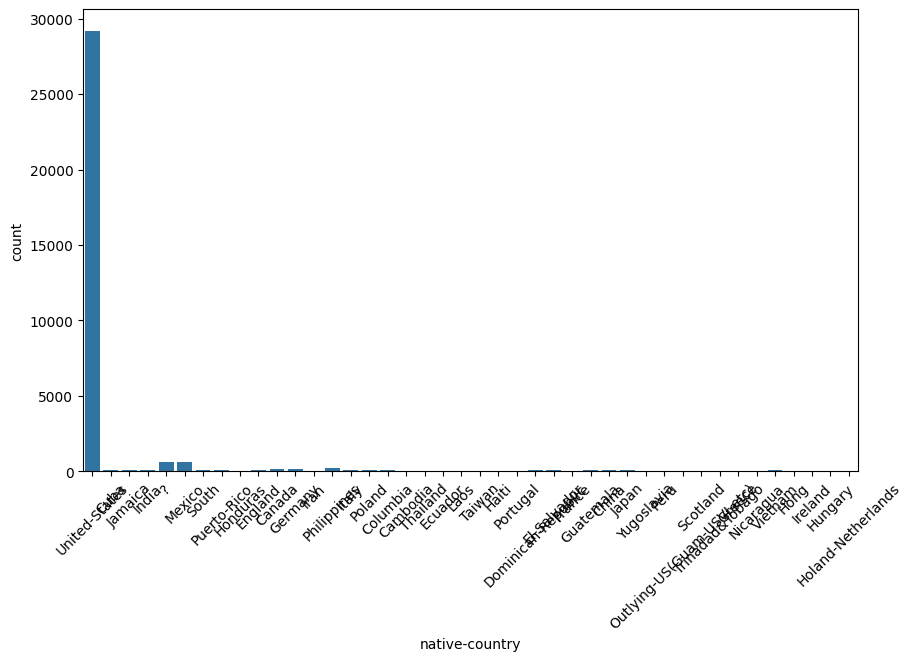

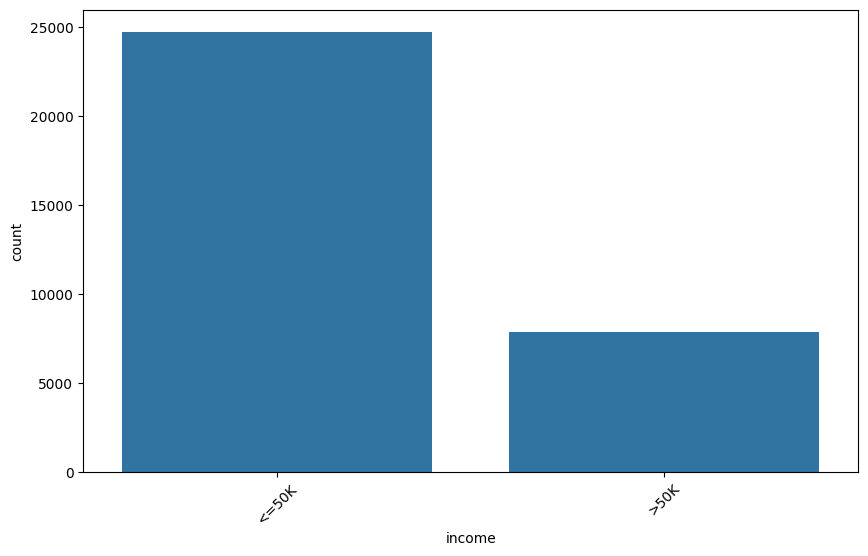

In [ ]:
# Plot categorical column distributions
categorical_columns = df.select_dtypes(include=['object']).columns
for column in categorical_columns:
    plt.figure(figsize=(10, 6))
    sns.countplot(x=column, data=df)
    plt.xticks(rotation=45)
    plt.show()

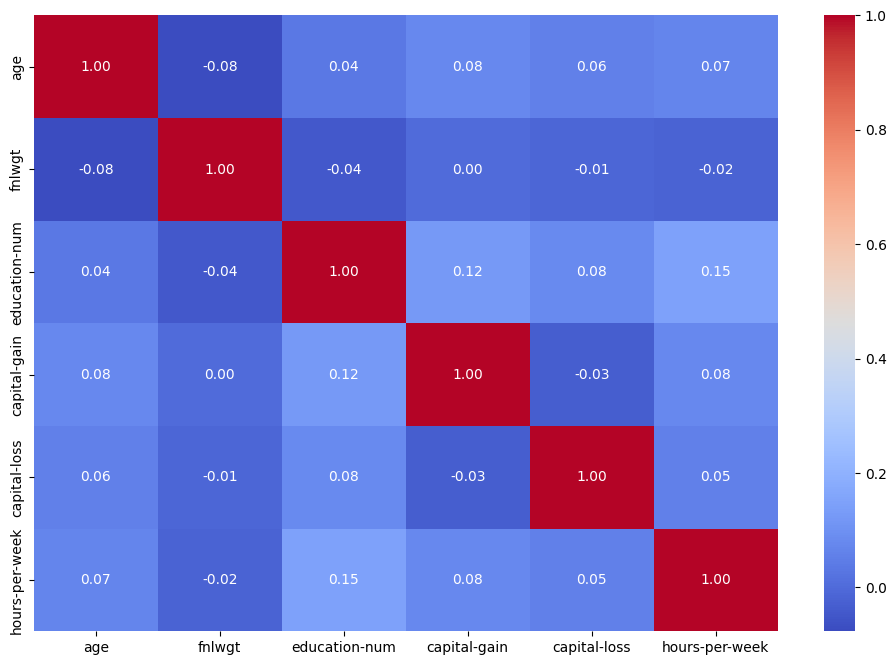

In [ ]:
# Correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(df[numerical_columns].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.show()

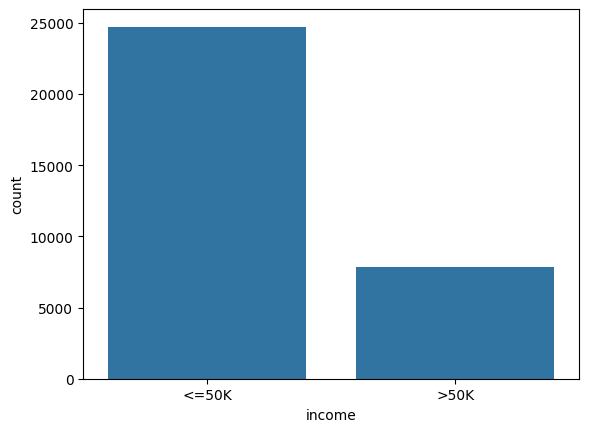

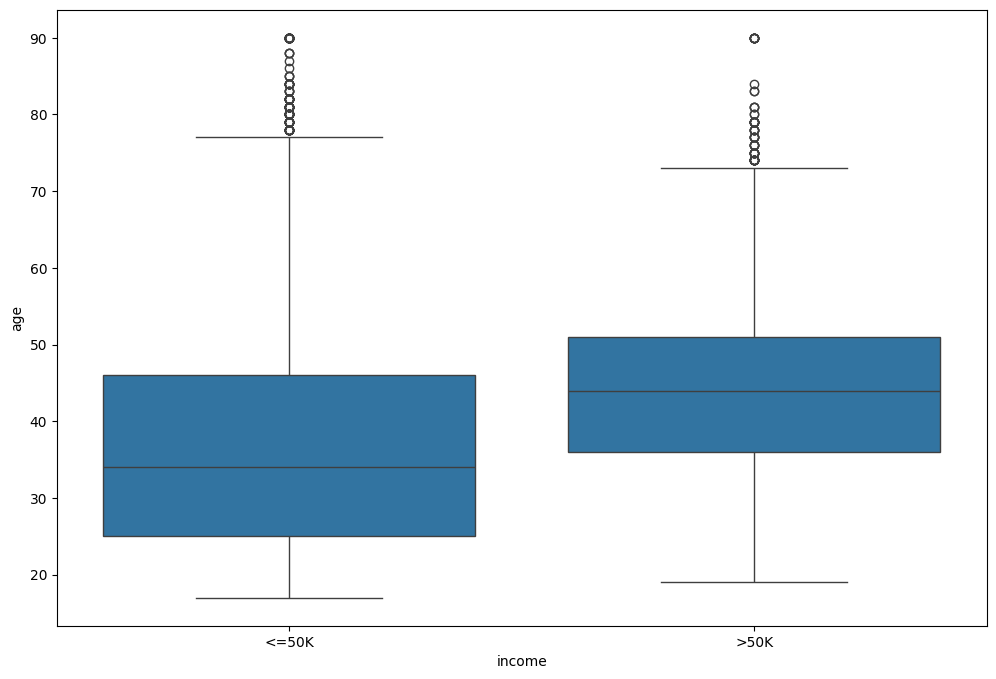

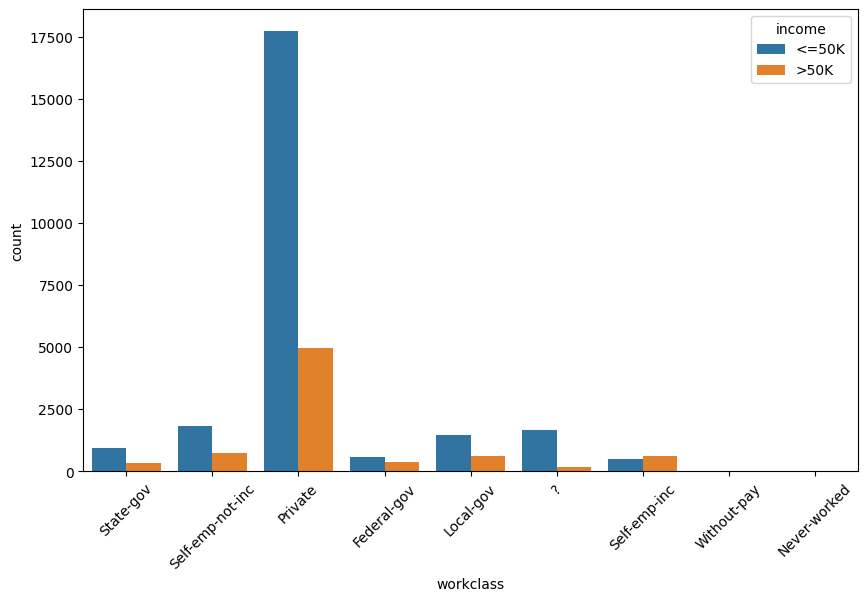

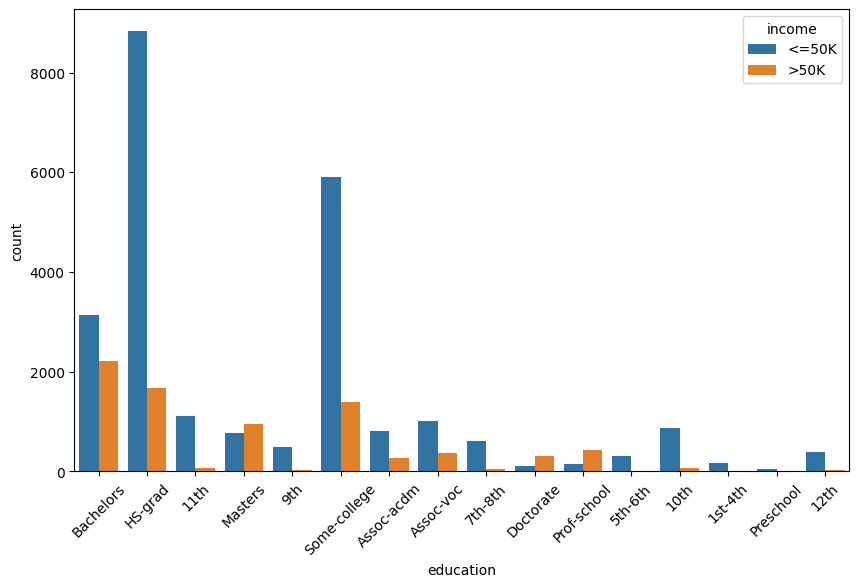

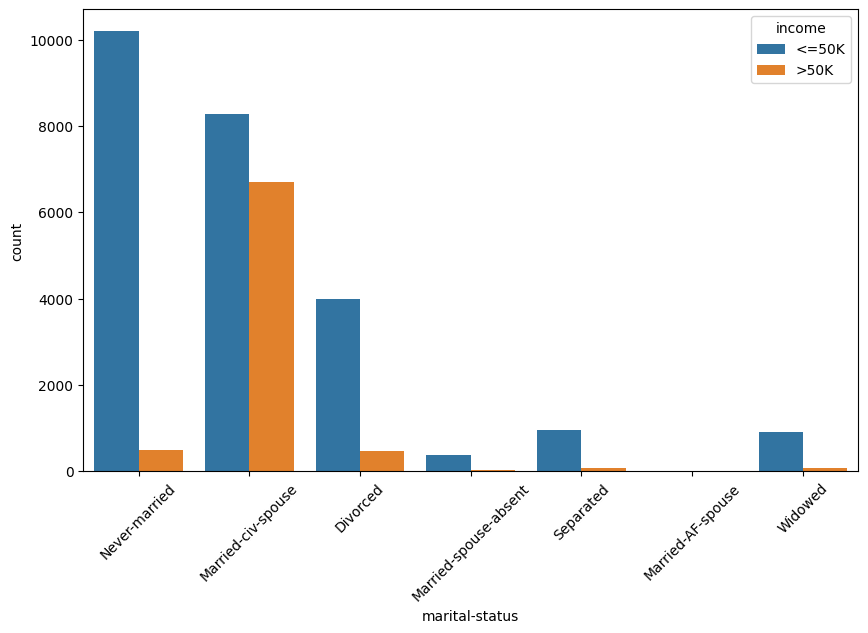

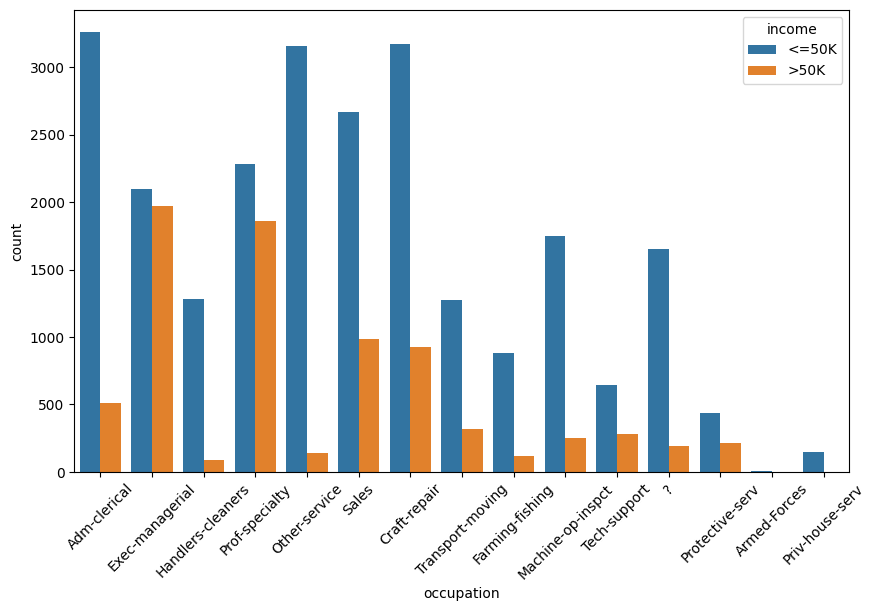

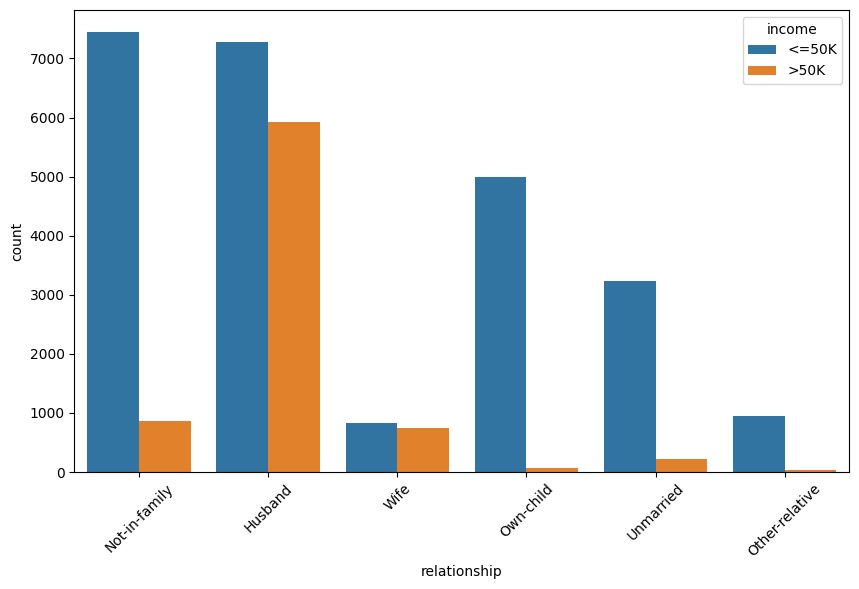

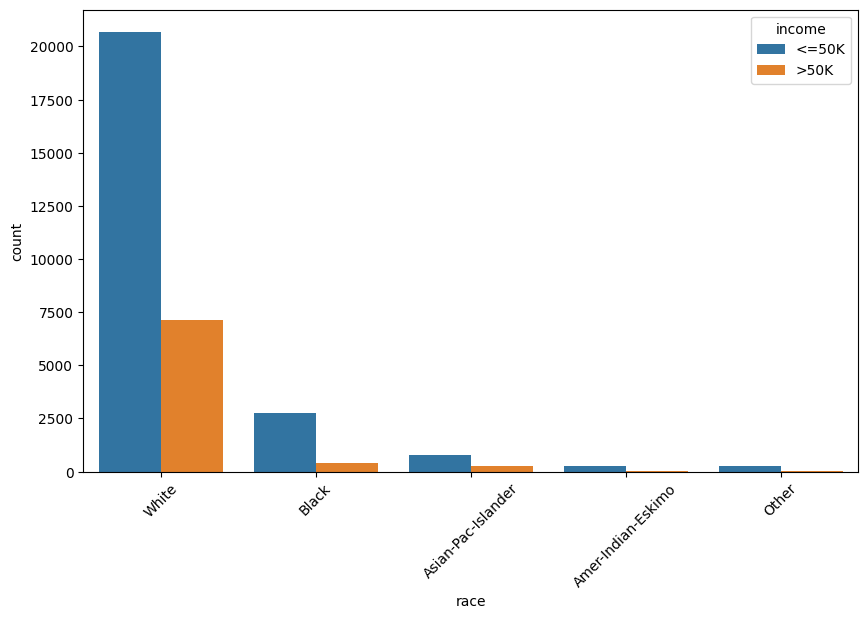

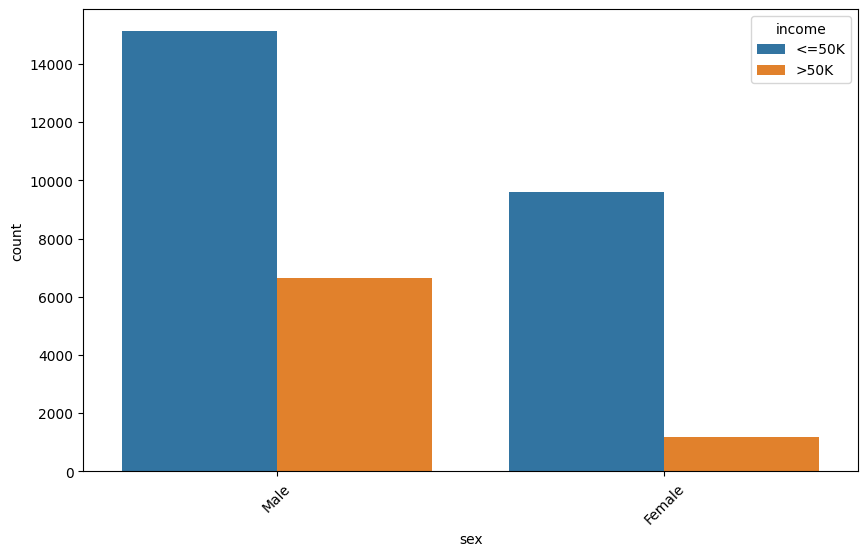

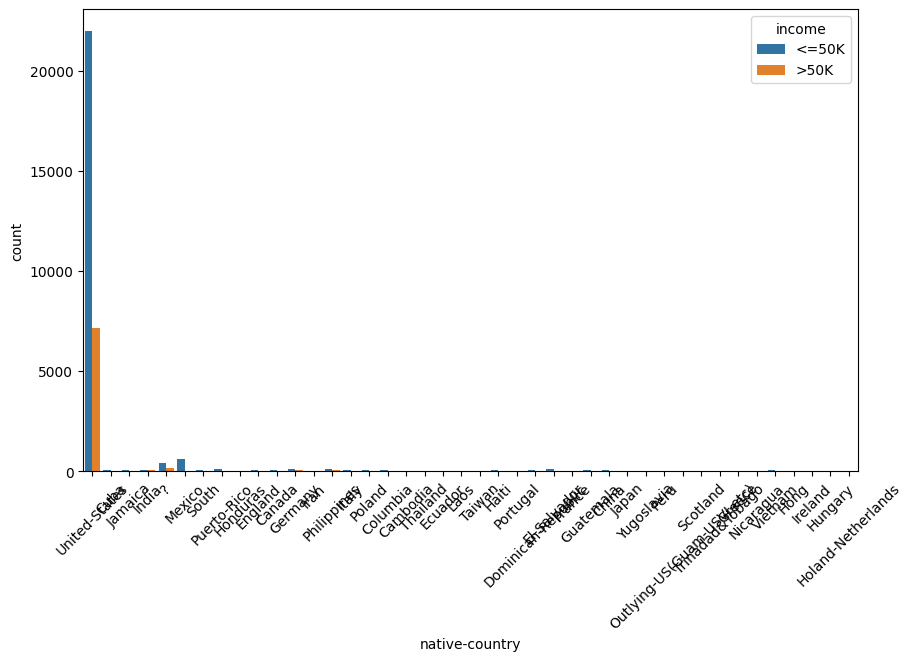

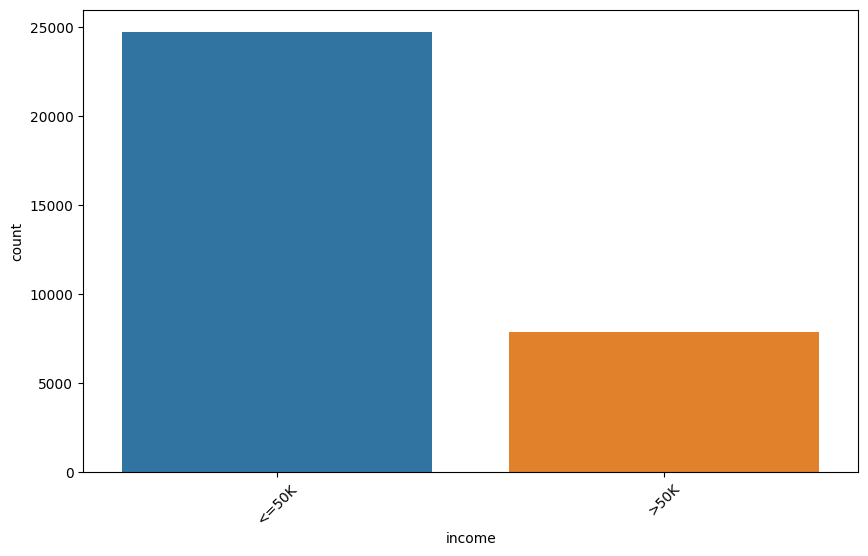

In [ ]:
# Countplot for income
sns.countplot(x='income', data=df)
plt.show()

# Boxplot for numerical features by income
plt.figure(figsize=(12, 8))
sns.boxplot(x='income', y='age', data=df)
plt.show()

# Income distribution by categorical features
for column in categorical_columns:
    plt.figure(figsize=(10, 6))
    sns.countplot(x=column, hue='income', data=df)
    plt.xticks(rotation=45)
    plt.show()

In [ ]:
# Check the number of rows before dropping missing values
rows_before = df.shape[0]

# Drop rows with missing values
df.dropna(inplace=True)

# Check the number of rows after dropping missing values
rows_after = df.shape[0]

# Calculate how many rows were deleted
deleted_rows = rows_before - rows_after
print(f"Number of rows deleted: {deleted_rows}")


Number of rows deleted: 0


# ✅ Baseline model training (Logistic Regression)

In [ ]:
# Encode categorical features
for col in ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']:
    df[col] = LabelEncoder().fit_transform(df[col])

In [ ]:
df['income'] = df['income'].apply(lambda x: 1 if x == '>50K' else 0)

In [ ]:
# Split dataset
X = df.drop(columns=['income'])
y = df['income']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Standardize numeric features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# Train logistic regression model
model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [ ]:
# Evaluate model
print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))


Accuracy: 0.8246583755565792
              precision    recall  f1-score   support

           0       0.85      0.94      0.89      4942
           1       0.71      0.46      0.56      1571

    accuracy                           0.82      6513
   macro avg       0.78      0.70      0.72      6513
weighted avg       0.81      0.82      0.81      6513



We might notice a bias against Class 1 (>50K earners)
* 🔹 Lower recall (46%) suggests the model fails to identify a significant portion of high-income individuals.
* 🔹 This could be due to class imbalance (4942 vs. 1571 samples).
* ==> If underrepresented groups are more likely to have lower incomes, the model might reinforce that bias.

# ✅ Fairness evaluation (using fairlearn)

In [ ]:
# Fairness Analysis
sensitive_feature = df['sex'][X_test.argmax(axis=1)]  # Gender as a sensitive attribute
dp_diff = demographic_parity_difference(y_test, y_pred, sensitive_features=sensitive_feature)
eqo_diff = equalized_odds_difference(y_test, y_pred, sensitive_features=sensitive_feature)
print("Demographic Parity Difference:", dp_diff)
print("Equalized Odds Difference:", eqo_diff)


Demographic Parity Difference: 0.05329816886744618
Equalized Odds Difference: 0.047237952669235


We notice some bias in the model
* Demographic Parity Difference (DPD) = 0.0533 → The predicted outcomes are 5.3% different across gender groups, meaning one group has a slight advantage in positive predictions.
* Equalized Odds Difference (EOD) = 0.0472 → The true positive rates and false positive rates differ by 4.7% between groups, suggesting a mild disparity in how the model treats different groups when making decisions.

# ✅ Bias mitigation techniques

In [ ]:
# Bias Mitigation using Threshold Optimizer
threshold_optimizer = ThresholdOptimizer(estimator=model, constraints="demographic_parity", prefit=True)
threshold_optimizer.fit(X_train, y_train, sensitive_features=df['sex'][X_train.argmax(axis=1)])
y_pred_fair = threshold_optimizer.predict(X_test, sensitive_features=df['sex'][X_test.argmax(axis=1)])


In [ ]:
# Evaluate fairness after mitigation
dp_diff_fair = demographic_parity_difference(y_test, y_pred_fair, sensitive_features=sensitive_feature)
eqo_diff_fair = equalized_odds_difference(y_test, y_pred_fair, sensitive_features=sensitive_feature)
print("Fair Model - Demographic Parity Difference:", dp_diff_fair)
print("Fair Model - Equalized Odds Difference:", eqo_diff_fair)

Fair Model - Demographic Parity Difference: 0.0018107299627052598
Fair Model - Equalized Odds Difference: 0.10080796661734637


**Analysis of Bias Mitigation Results**
* Demographic Parity Difference (DPD): 0.0018 ✅ → Huge improvement (was 0.0533). Almost perfect demographic parity!
* Equalized Odds Difference (EOD): 0.1008  → Increased significantly (was 0.0472). The model now has worse disparity in true positive and false positive rates across groups ❗️
* ==> This means our model now ensures almost equal selection rates across groups, meaning the same proportion of people get classified as >50K regardless of gender.
However, Equalized Odds Difference increased, meaning the model treats groups differently in terms of errors (i.e., misclassification rates differ more between groups).

This is a **classic fairness-performance tradeoff**:
* ✔️ Fixing Demographic Parity may worsen Equalized Odds
* ✔️ Fixing Equalized Odds may worsen Demographic Parity

# ✅ Explainability analysis (using SHAP)

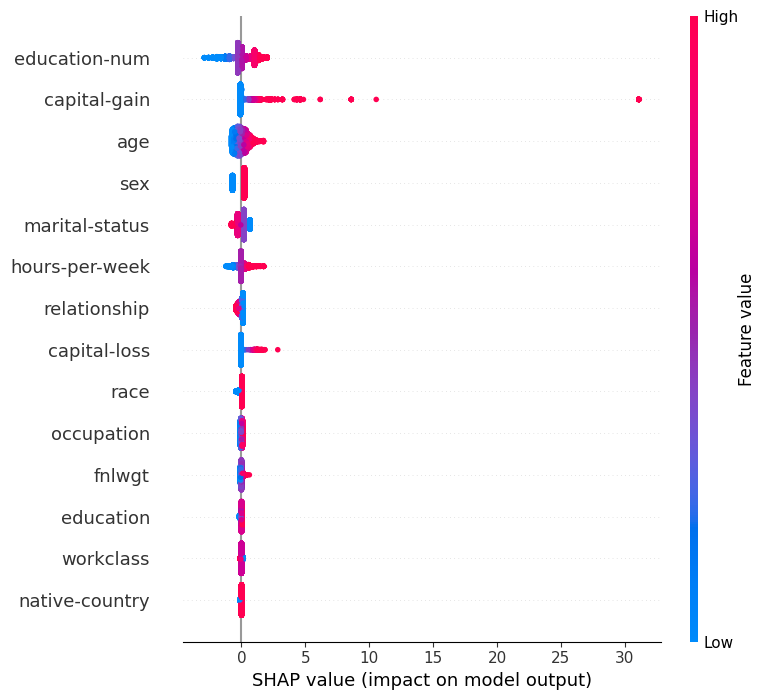

In [ ]:
# SHAP Explainability
explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test)
shap.summary_plot(shap_values, X_test, feature_names=X.columns)

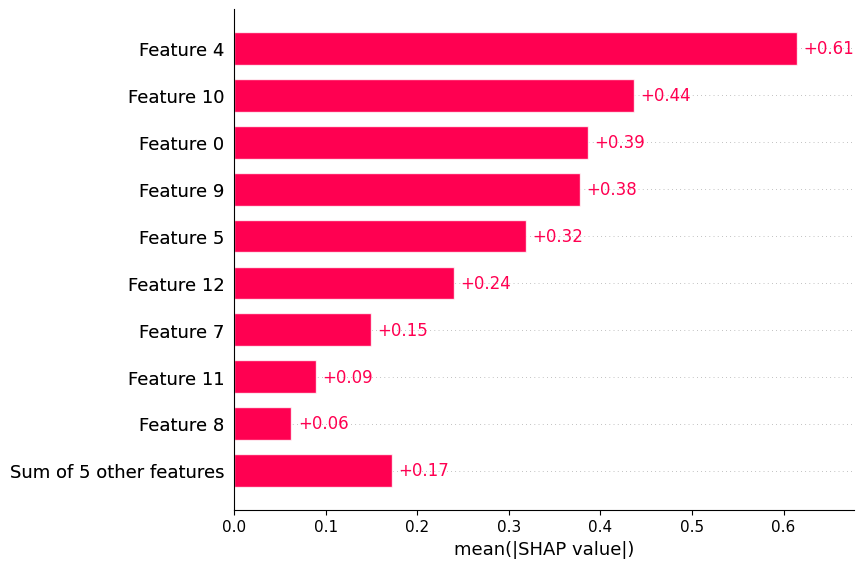

In [ ]:
# Feature Importance Analysis
shap.plots.bar(shap_values)

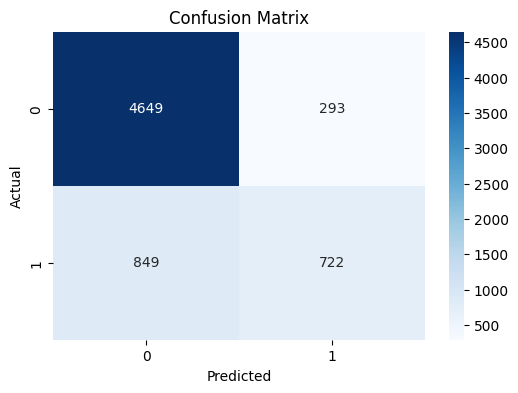

In [ ]:
# Confusion Matrix Visualization
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

# ✅ Conclusion